In [1]:
import paarti.utils.maos_utils as mu
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from pathlib import Path
from astropy.io import fits
from scipy.io import readsav

In [2]:
names = []
datecol = []
sky_paths = []
# Root of directory where sky files live
skyroot = Path("/Users/bdigia/work/ao/airopa_input/")
dates = [f.as_posix()[-16:-8] for f in skyroot.glob("*/")]
true_names = []
for date in dates:
    name = [f.as_posix()[-14:-9] for f in skyroot.glob(f"{date}nirc2_kp/*_psf.fits")]
    paths = [f.as_posix() for f in skyroot.glob(f"{date}nirc2_kp/*_psf.fits")]
    names.extend(name)
    temp = np.full(len(name), date)
    datecol.extend(temp.tolist())
    sky_paths.extend(paths)
    for path in paths:
        with fits.open(path) as fits_file:
            hdu = fits_file[0]
            hdr = hdu.header
            true_name = hdr['FILENAME']
        true_names.append(true_name)
     
names = np.array(names)
datecol = np.array(datecol)
namesanddates = np.column_stack((names, datecol))
truenamesanddates = np.column_stack((true_names, datecol))

In [3]:
telem_home = Path('/g/lu/data/keck_telemetry/')    
telem_paths = []
telem_mask = np.empty(len(truenamesanddates), dtype=bool)
for i, sky in enumerate(truenamesanddates):
    paths = [f.as_posix() for f in telem_home.glob(f"{sky[1]}/sdata90*/nirc*/*/n*_LGS_trs.sav")]
    telem_paths.extend(paths)
    if paths == []:
        # No telemetry exists for this observation date
        telem_mask[i] = False
    else:
        # Telemetry exists for this observation date
        telem_mask[i] = True

In [4]:
n0058 = readsav('/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0058_LGS_trs.sav')
n0059 = readsav('/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0059_LGS_trs.sav')
n0060 = readsav('/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0060_LGS_trs.sav')
n0061 = readsav('/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0061_LGS_trs.sav')
n0062 = readsav('/g/lu/data/keck_telemetry/20170823/sdata902/nirc3/2017aug23/n0062_LGS_trs.sav')

In [5]:
# Telemetry quantities for MAOS inputs -- adjust to MAOS-desired units
n0058_strap_bkgrnd = np.mean(n0058.apd_sky_back)
n0058_shwfs_siglev = np.mean(n0058.a.subapintensity[0])
n0058_strap_siglev = np.mean(n0058.b.apdcounts[0])
telemetry = [n0058, n0059, n0060, n0061, n0062]
names = ['n0058_c2058_', 'n0059_c2059_', 'n0060_c2060_', 'n0061_c2061_', 'n0062_c2062_']

In [6]:
files = ["/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2058_psf.fits",
         "/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2059_psf.fits",
         "/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2060_psf.fits",
         "/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2061_psf.fits",
         "/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2062_psf.fits"]
baseroot = Path("/Users/bdigia/work/ao/keck/maos/keck/my_base") 
# Simulation seeds
seeds = np.array([1, 1000, 5000, 10000])

for i, file in enumerate(files):
    with fits.open(file) as fits_file:
        hdu = fits_file[0]
        hdr = hdu.header

        # Zenith angle
        angle = np.degrees(np.arccos(1.0/float(hdr['AIRMASS'])))
        # Wavelength at which to run MAOS (microns)
        wvl = float(hdr['TARGWAVE']) * 1.0e-6 # multiply by 1e-6 to convert from microns to m
        # STRAP WFS integration time (milli-sec)
        if 'STINTTIM' not in hdr:
            continue
        hdr_strap_int_time = float(hdr['STINTTIM'])
        # SHWFS frame rate (Hz)
        hdr_shwfs_frame_rate = float(hdr['WSFRRT'])
        hdr_strap_frame_rate = (1.0/hdr_strap_int_time)*1000.0

        # Set sim_dt to fastest WFS readout rate in Hz
        if hdr_shwfs_frame_rate > hdr_strap_frame_rate:
            max_frame_rate = hdr_shwfs_frame_rate
            print(f"SHWFS frame rate is maximum = {max_frame_rate} Hz >= {hdr_strap_frame_rate}")
        else:
            max_frame_rate = hdr_strap_frame_rate
            print(f"STRAP frame rate is maximum = {max_frame_rate} Hz >= {hdr_shwfs_frame_rate}")

        sim_dt = 1.0/max_frame_rate
        hdr_shwfs_int_time = (1.0/hdr_shwfs_frame_rate)*1000.0 # ms
        # sim_dt = (1.0/472.0)*1000.0 # ms

        howfs_dtrat = (sim_dt / hdr_shwfs_int_time)*1000.0
        strap_dtrat = (sim_dt / hdr_strap_int_time)*1000.0
        # Compose powfs.dtrat array for input into MAOS config command override
        if howfs_dtrat < 1:
            howfs_dtrat = 1
        elif strap_dtrat < 1:
            strap_dtrat = 1
        dtrat = [int(howfs_dtrat), int(strap_dtrat), 7080]

        # Calculate atm parameters
        fried, turbpro, windspds, winddrcts, _, _, _, _, _, _ = mu.estimate_on_sky_conditions(file, 
                                                                                              "/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/", 
                                                                                              verbose=False)
        # Size of on-sky image
        # if int(hdr['NAXIS1']) == int(hdr['NAXIS2']):
        #     size = int(hdr['NAXIS1'])
        # else:
        #     size = min(int(hdr['NAXIS1']), int(hdr['NAXIS2']))

        # MAOS seems to give weird warnings when input evl.psfsize parameter is odd
        # if size % 2 != 0:
        #     size -= 1

        size = 256
        _, howfs_nearecon, _, howfs_bkgrnd = mu.keck_nea_photons(8.1, 'LGSWFS', hdr_shwfs_int_time/1000.0)
        _, strap_nearecon, _, _ = mu.keck_nea_photons(14.0, 'STRAP', hdr_strap_int_time/1000.0)

        # Compose MAOS intensity input parameters based on telemetry
        telem = telemetry[i]
        strap_bkgrnd = np.mean(telem.apd_sky_back)
        # howfs_siglev = np.mean(telem.a.subapintensity[0]) 
        strap_siglev = np.mean(telem.b.apdcounts[0]) * 0.1 # try STRAP gain of 0.1 from keck_nea_photons

        shwfs_gain = 0.508 # e-/ADU 
        howfs_siglev = ( np.mean(telem.a.subapintensity[0]) * shwfs_gain )

        nearecon = [howfs_nearecon, strap_nearecon, 8.4]
        siglev = [howfs_siglev, strap_siglev, 3723]
        bkgrnd = [howfs_bkgrnd, strap_bkgrnd, 25.3]

        mode = 'surf_wfs1'
        surf_cmd = ["Keck_ncpa_rmswfe130nm.fits", "'r0=0.36;l0=3.39;ht=40000;slope=-2; SURFWFS=1; SURFEVL=1; seed=10;'"]
        psd_file = "PSD_Keck_ws26.47mas_vib26mas_rad2.fits"

        for seed in seeds:
            # Must be in MAOS simulation directory to run successfully
            if os.getcwd() != baseroot.as_posix():
                os.chdir(baseroot)

            # Run sim with sub ap intensity input unchanged
            maos_cmd = f"maos -o A_keck_scao_lgs_gc_telemetry_input_comp_{names[i]}seed{seed}_epoch20170823 -c A_keck_scao_lgs_gc.conf evl.psfsize={size} sim.seeds={seed} evl.wvl={wvl} sim.dt={sim_dt} sim.dtref={sim_dt} powfs.dtrat={dtrat} sim.zadeg={angle} powfs.siglev={siglev} powfs.bkgrnd={bkgrnd} powfs.nearecon={nearecon} sim.wspsd={psd_file} atm.r0z={fried.value} atm.wt={turbpro} atm.ws={windspds} atm.wddeg={winddrcts} surf={surf_cmd} -O"
            os.system(maos_cmd)

STRAP frame rate is maximum = 1000.0 Hz >= 1000.0
Assumptions:
  Wave-Front Sensor       = LGSWFS
  Pupil Aperture Diameter = 0.56 m (assumed square)
  Throughput (w QE)       = 0.32
  Plate Scale             = 3.000 arcsec/pix
  Spot Size Diameter      = 1.500 arcsec
  Filter                  = R
  Readnoise               = 6.5 e-
  Pixels per Subaperture  = 4
  Integration Time        = 0.0010 s
  Guide Star Magnitude    = 8.10

Outputs:
  N_photons from star (powfs.siglev for MAOS config): 600.357
  N_photons per pixel from background (powfs.bkgrnd):   0.071
  SNR:                                   21.640
  NEA (powfs.nearecon): 69.315 mas
Assumptions:
  Wave-Front Sensor       = STRAP
  Pupil Aperture Diameter = 9.57 m (assumed square)
  Throughput (w QE)       = 0.32
  Plate Scale             = 1.300 arcsec/pix
  Spot Size Diameter      = 0.490 arcsec
  Filter                  = R
  Readnoise               = 0.1 e-
  Pixels per Subaperture  = 4
  Integration Time        = 0.0010 s

Warning(readcfg.c:406): sim.apfsm has been renamed to powfs.apfsm.
Warning(readcfg.c:406): sim.epfsm has been renamed to powfs.epfsm.
Warning(readcfg.c:406): sim.alfsm has been renamed to powfs.alfsm.
Warning(readcfg.c:406): sim.commonfsm has been renamed to powfs.commonfsm.
Warning(readcfg.c:406): sim.idealfsm has been renamed to powfs.idealfsm.
Warning(readcfg.c:406): sim.zetafsm has been renamed to powfs.zetafsm.
Warning(readcfg.c:406): sim.f0fsm has been renamed to powfs.f0fsm.
Warning(readcfg.c:406): surf has been renamed to ncpa.surf.
Warning(readcfg.c:406): tsurf has been renamed to ncpa.tsurf.
Warning(readcfg.c:406): surf has been renamed to ncpa.surf.


loaded  82 ( 75 new) records from '/Users/jlu/code/maos/config/maos/powfs_common.conf'
loaded  44 ( 38 new) records from '/System/Volumes/Data/mnt/g2/scratch/bdigia/work/ao/keck/maos/keck/my_base/powfs_none.conf'
loaded  44 (  0 new) records from '/System/Volumes/Data/mnt/g2/scratch/bdigia/work/ao/keck/maos/keck/my_base/keck_shwfs_lgs.conf'
loaded  44 (  0 new) records from '/System/Volumes/Data/mnt/g2/scratch/bdigia/work/ao/keck/maos/keck/my_base/keck_shwfs_ttf_strap.conf'
loaded  44 (  0 new) records from '/System/Volumes/Data/mnt/g2/scratch/bdigia/work/ao/keck/maos/keck/my_base/keck_shwfs_twfs_lbwfs.conf'
loaded   0 (  0 new) records from '/System/Volumes/Data/mnt/g2/scratch/bdigia/work/ao/keck/maos/keck/my_base/keck_wfs_lgs_strap_lbwfs.conf'
loaded  71 ( 71 new) records from '/Users/jlu/code/maos/config/maos/recon.conf'
loaded  80 ( 80 new) records from '/Users/jlu/code/maos/config/maos/dbg.conf'
loaded   4 (  4 new) records from '/Users/jlu/code/maos/config/maos/fit_oa.conf'
loade

Warning(accphi.c:478): 7318 points not covered by input screen


iwvl 0: Science PSF is using grid size of 700. The PSF will sum to 6.57979009545127
After setup_aper:	16.7 MiB.

Setting up powfs 0 geom

There are 36 points in each subaperture of 0.563m.
There are 248 valid subaperture.

Setting up powfs 1 geom

There are 176 points in each subaperture of 11m.
There are 1 valid subaperture.

Setting up powfs 2 geom

There are 16 points in each subaperture of 0.5m.
There are 290 valid subaperture.
After setup_powfs_init:	56.9 MiB.

Setting up reconstructor geometry.

PLOC is 43x43, with sampling of 0.28m (not square)
    DM 0: grid is 23 x 23
FLOC is 43x43, with sampling of 0.28m (not square)
Tomography grid is not square:
    layer 0: xloc grid is  72 x  72, sampling is 0.281 m,  1489 points
    layer 1: xloc grid is  72 x  72, sampling is 0.280 m,  1524 points
    layer 2: xloc grid is  72 x  72, sampling is 0.278 m,  1546 points
    layer 3: xloc grid is  72 x  72, sampling is 0.275 m,  1598 points
    layer 4: xloc grid is  72 x  72, sampling is 0

...

There are 248 valid subaperture.

Setting up powfs 1 geom

There are 176 points in each subaperture of 11m.
There are 1 valid subaperture.

Setting up powfs 2 geom

There are 16 points in each subaperture of 0.5m.
There are 290 valid subaperture.
After setup_powfs_init:	55.3 MiB.

Setting up reconstructor geometry.

PLOC is 43x43, with sampling of 0.28m (not square)
    DM 0: grid is 23 x 23
FLOC is 43x43, with sampling of 0.28m (not square)
Tomography grid is not square:
    layer 0: xloc grid is  72 x  72, sampling is 0.281 m,  1489 points
    layer 1: xloc grid is  72 x  72, sampling is 0.280 m,  1524 points
    layer 2: xloc grid is  72 x  72, sampling is 0.278 m,  1547 points
    layer 3: xloc grid is  72 x  72, sampling is 0.275 m,  1598 points
    layer 4: xloc grid is  72 x  72, sampling is 0.268 m,  1727 points
    layer 5: xloc grid is  72 x  72, sampling is 0.255 m,  1994 points
    layer 6: xloc grid is  72 x  72, sampling is 0.229 m,  2683 points
Setting up surface OPD

Su

Warning(readcfg.c:406): sim.apfsm has been renamed to powfs.apfsm.
Warning(readcfg.c:406): sim.epfsm has been renamed to powfs.epfsm.
Warning(readcfg.c:406): sim.alfsm has been renamed to powfs.alfsm.
Warning(readcfg.c:406): sim.commonfsm has been renamed to powfs.commonfsm.
Warning(readcfg.c:406): sim.idealfsm has been renamed to powfs.idealfsm.
Warning(readcfg.c:406): sim.zetafsm has been renamed to powfs.zetafsm.
Warning(readcfg.c:406): sim.f0fsm has been renamed to powfs.f0fsm.
Warning(readcfg.c:406): surf has been renamed to ncpa.surf.
Warning(readcfg.c:406): tsurf has been renamed to ncpa.tsurf.
Warning(readcfg.c:406): surf has been renamed to ncpa.surf.
Warning(accphi.c:478): 7318 points not covered by input screen


Tomography grid is not square:
    layer 0: xloc grid is  72 x  72, sampling is 0.281 m,  1489 points
    layer 1: xloc grid is  72 x  72, sampling is 0.280 m,  1524 points
    layer 2: xloc grid is  72 x  72, sampling is 0.278 m,  1547 points
    layer 3: xloc grid is  72 x  72, sampling is 0.275 m,  1598 points
    layer 4: xloc grid is  72 x  72, sampling is 0.268 m,  1727 points
    layer 5: xloc grid is  72 x  72, sampling is 0.255 m,  1994 points
    layer 6: xloc grid is  72 x  72, sampling is 0.229 m,  2683 points
Setting up surface OPD

Surface 0:
Loading surface OPD from Keck_ncpa_rmswfe130nm.fits
Does not contain SURFEVL. Assume it covers all evaluation directions.
Does not contain SURFWFS, Assume it covers all WFS.

Surface 1:
Generating surface OPD from r0=0.36;l0=3.39;ht=40000;slope=-2; SURFWFS=1; SURFEVL=1; seed=10;
Generating screen with r0=0.36, L0=3.39, dx=0.015625, slope=-2, nx=2048, seed=10
Layer 0: Randn: 0.19 FFT: 0.09 Copy: 0.01 seconds.
Covers evl 0
Covers WFS 0

Warning(readcfg.c:406): sim.apfsm has been renamed to powfs.apfsm.
Warning(readcfg.c:406): sim.epfsm has been renamed to powfs.epfsm.
Warning(readcfg.c:406): sim.alfsm has been renamed to powfs.alfsm.
Warning(readcfg.c:406): sim.commonfsm has been renamed to powfs.commonfsm.
Warning(readcfg.c:406): sim.idealfsm has been renamed to powfs.idealfsm.
Warning(readcfg.c:406): sim.zetafsm has been renamed to powfs.zetafsm.
Warning(readcfg.c:406): sim.f0fsm has been renamed to powfs.f0fsm.
Warning(readcfg.c:406): surf has been renamed to ncpa.surf.
Warning(readcfg.c:406): tsurf has been renamed to ncpa.tsurf.
Warning(readcfg.c:406): surf has been renamed to ncpa.surf.
Warning(accphi.c:478): 7318 points not covered by input screen


Tomography grid is not square:
    layer 0: xloc grid is  72 x  72, sampling is 0.281 m,  1489 points
    layer 1: xloc grid is  72 x  72, sampling is 0.280 m,  1524 points
    layer 2: xloc grid is  72 x  72, sampling is 0.278 m,  1547 points
    layer 3: xloc grid is  72 x  72, sampling is 0.275 m,  1598 points
    layer 4: xloc grid is  72 x  72, sampling is 0.268 m,  1727 points
    layer 5: xloc grid is  72 x  72, sampling is 0.255 m,  1994 points
    layer 6: xloc grid is  72 x  72, sampling is 0.229 m,  2683 points
Setting up surface OPD

Surface 0:
Loading surface OPD from Keck_ncpa_rmswfe130nm.fits
Does not contain SURFEVL. Assume it covers all evaluation directions.
Does not contain SURFWFS, Assume it covers all WFS.

Surface 1:
Generating surface OPD from r0=0.36;l0=3.39;ht=40000;slope=-2; SURFWFS=1; SURFEVL=1; seed=10;
Generating screen with r0=0.36, L0=3.39, dx=0.015625, slope=-2, nx=2048, seed=10
Layer 0: Randn: 0.19 FFT: 0.10 Copy: 0.01 seconds.
Covers evl 0
Covers WFS 0

In [6]:
folders = ["A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed10000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed5000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed10000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed1000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed1_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0059_c2059_seed5000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed10000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed1000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed1_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0060_c2060_seed5000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed10000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed1000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed1_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0061_c2061_seed5000_epoch20170823/",
"A_keck_scao_lgs_gc_telemetry_input_comp_n0062_c2062_seed10000_epoch20170823/"]

frames = ["n0058", "n0059", 'n0060', 'n0061', 'n0062']
basedir = Path("/Users/bdigia/work/ao/keck/maos/keck/my_base")

In [8]:
strehls = []
strehl_stds = []
fwhms = []
fwhm_stds = []
rmswfes = []
rmswfe_stds = []
tot_maos_wfes = []
ho_maos_wfes = []
tt_maos_wfes = []
seeds = np.array([1, 1000, 5000, 10000])
sky_sr = []
sky_fwhm = []
sky_rmswfe = []
for i, frame in enumerate(frames):
    for seed in seeds:
        dir = basedir.as_posix() + f"/A_keck_scao_lgs_gc_telemetry_input_comp_{frame}_c2{frame[2:]}_seed{seed}_epoch20170823/"
        skydir = [f"/Users/bdigia/work/ao/airopa_input/20170823nirc2_kp/c2{frame[2:]}_psf.fits"]
        strehls_to_avg = []
        fwhms_to_avg = []
        rmswfes_to_avg = []
        tot_maos_to_avg = []
        ho_maos_to_avg = []
        tt_maos_to_avg = []
        # out_file = f"maos_comp_{framedates[i][0]}_epoch{framedates[i][1]}_seed{seed}_metrics.txt"
        out_file = "temp.txt"
        try:
            maos_seed_strehls, maos_seed_fwhms, maos_seed_rmswfes = mu.calc_strehl(dir, out_file, sim_seed=seed, apersize=0.6) # 0.6 arcsec aperture size from spot check analysis
            sky_strehls, sky_fwhms, sky_rmswfes = mu.calc_strehl_on_sky(skydir, "temp.txt")
            print(sky_strehls)
            _, maos_cl_metrics, _, _ = mu.print_wfe_metrics(directory=dir, seed=seed)
            tot_maos_err = maos_cl_metrics[0]
            tt_maos_err = maos_cl_metrics[1]
            ho_maos_err = maos_cl_metrics[2]
        except Exception as error:
            print(f"Error calculating metrics: {error} --> using NaN for metrics")
            maos_seed_strehls = [np.nan]
            maos_seed_fwhms = [np.nan]
            maos_seed_rmswfes = [np.nan]
            tot_maos_err = np.nan
            tt_maos_err = np.nan
            ho_maos_err = np.nan
            
        # Store values at 2.12 microns (last values)
        strehls_to_avg.append(maos_seed_strehls[-1])
        fwhms_to_avg.append(maos_seed_fwhms[-1])
        rmswfes_to_avg.append(maos_seed_rmswfes[-1])
        tot_maos_to_avg.append(tot_maos_err)
        ho_maos_to_avg.append(ho_maos_err)
        tt_maos_to_avg.append(tt_maos_err)
    strehls.append(np.mean(strehls_to_avg))
    strehl_stds.append(np.std(strehls_to_avg))
    fwhms.append(np.mean(fwhms_to_avg))
    fwhm_stds.append(np.std(fwhms_to_avg))
    rmswfes.append(np.mean(rmswfes_to_avg))
    rmswfe_stds.append(np.std(rmswfes_to_avg))
    tot_maos_wfes.append(np.mean(tot_maos_to_avg))
    ho_maos_wfes.append(np.mean(ho_maos_to_avg))
    tt_maos_wfes.append(np.mean(tt_maos_to_avg))
    sky_sr.append(sky_strehls)
    sky_fwhm.append(sky_fwhms)
    sky_rmswfe.append(sky_rmswfes)

/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1_epoch20170823/evlpsfcl_1_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale = 0.0200277 arcsec/px
FWHM on iteration 1 = 50.57 mas | Empirical FWHM on iteration 1 = 59.79 mas
Error calculating metrics: too many values to unpack (expected 3) --> using NaN for metrics
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed1000_epoch20170823/evlpsfcl_1000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale = 0.0200277 arcsec/px
FWHM on iteration 1 = 50.57 mas | Empirical FWHM on iteration 1 = 55.36 mas
Error calculating metrics: too many values to unpack (expected 3) --> using NaN for metrics
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_telemetry_input_comp_n0058_c2058_seed5000_epoch20170823/evlpsfcl_5000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Sc

NameError: name 'sky_strehl' is not defined

ValueError: x and y must be the same size

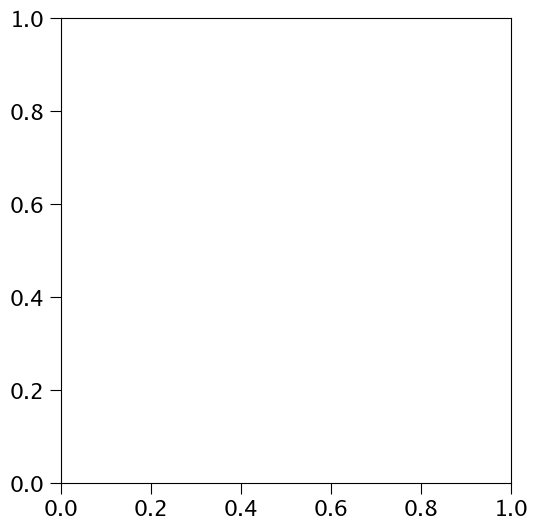

In [10]:
plt.scatter(strehls, sky_sr)
plt.xlim(0.0, 0.35)
plt.ylim(0.0, 0.35)
plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.title("On-Sky Strehls versus MAOS Strehls with telemetry input", fontsize=12)
plt.xlabel("MAOS Strehls", fontsize=10)
plt.ylabel("On-sky Strehls", fontsize=10)
plt.tight_layout()
plt.grid(True)

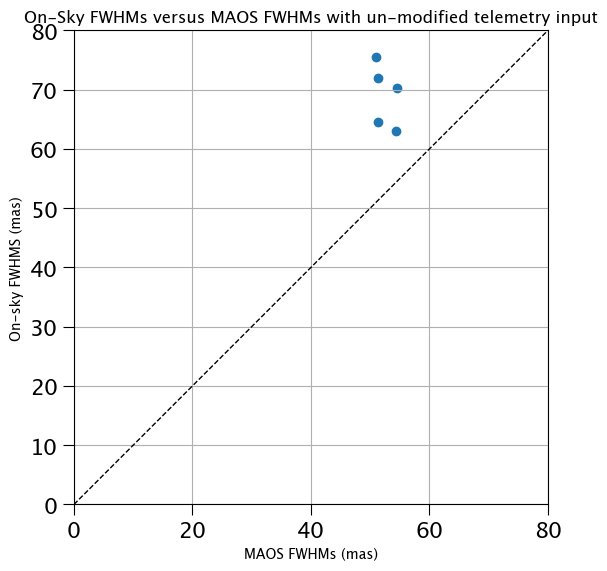

In [19]:
plt.scatter(fwhms, sky_fwhm)
plt.xlim(0.0, 80.0)
plt.ylim(0.0, 80.0)
plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.title("On-Sky FWHMs versus MAOS FWHMs with un-modified telemetry input", fontsize=12)
plt.xlabel("MAOS FWHMs (mas)", fontsize=10)
plt.ylabel("On-sky FWHMS (mas)", fontsize=10)
plt.tight_layout()
plt.grid(True)

In [ ]:
plt.scatter(tot_maos_wfes, sky_rmswfe)
plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.title("On-Sky RMS WFEs (Marechal) versus MAOS-computed TOT RMS WFEs", fontsize=12)
plt.xlabel("MAOS TOT RMS WFE (nm)", fontsize=10)
plt.ylabel("On-sky RMS WFE (nm)", fontsize=10)
plt.tight_layout()
plt.grid(True)